# Project 1 — SVM
## Credit Card Fraud Detection (small-scale)

Detecting fraudulent transactions from synthetic transaction features: amount, transaction hour, distance from home, merchant risk score.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 700
is_fraud = np.random.choice([0,1], n, p=[0.85,0.15])
amount = np.where(is_fraud==1, np.random.gamma(3, 150, n), np.random.gamma(2, 40, n))
txn_hour = np.where(is_fraud==1, np.random.choice(range(0,6), n), np.random.randint(0,24,n))
distance_from_home = np.where(is_fraud==1, np.random.gamma(4, 60, n), np.random.gamma(1, 8, n))
merchant_risk = np.where(is_fraud==1, np.random.uniform(0.5,1,n), np.random.uniform(0,0.5,n))

df = pd.DataFrame({'amount': amount, 'txn_hour': txn_hour, 'distance_from_home': distance_from_home,
                    'merchant_risk': merchant_risk, 'is_fraud': is_fraud})
df.head()


,amount,txn_hour,distance_from_home,merchant_risk,is_fraud
0,16.171720,9,5.917039,0.495356,0
1,411.722950,3,183.041927,0.832050,1
2,34.880356,20,4.271838,0.253228,0
3,72.784748,22,2.844815,0.422201,0
4,78.293251,15,11.029965,0.119612,0


## 2. Preprocessing

In [3]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Train Model

In [4]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


## 4. Evaluate

In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1:", f1_score(y_test, y_pred, average='weighted', zero_division=0))
print()
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       118
           1       1.00      1.00      1.00        22

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



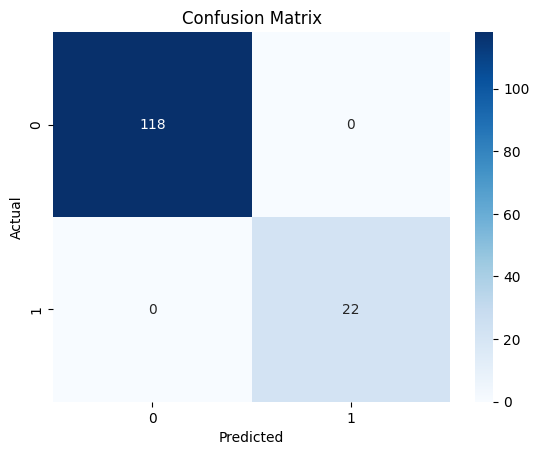

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()


## Takeaways
- `class_weight='balanced'` matters a lot here since fraud is rare — otherwise the model may just predict "not fraud" for everything.
- Try both `kernel='linear'` and `kernel='rbf'` to see if the fraud boundary is linear or needs the RBF's flexibility.
- Next steps: use `GridSearchCV` over `C` and `gamma` together — they interact (e.g., high C + high gamma = severe overfitting).

---
# Project 2 — Your Turn
**Dataset:** Iris dataset (`sklearn.datasets.load_iris`) — the classic SVM demo dataset, classify 3 flower species from petal/sepal measurements.

```python
from sklearn.datasets import load_iris
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
```
**Tasks:** scale features, train SVM with different kernels (`linear`, `rbf`, `poly`), compare accuracy, and visualize decision boundaries using just 2 features at a time.
